In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

import numpy as np

import matplotlib.pyplot as plt

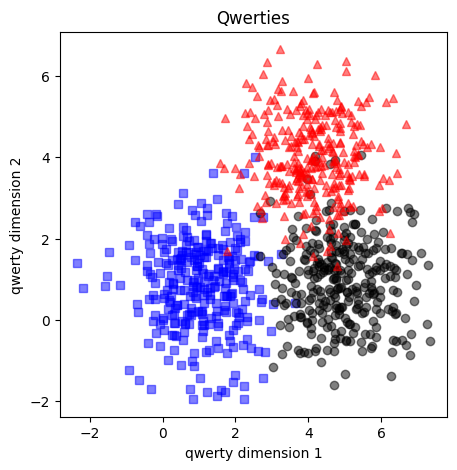

In [11]:
nPerClust = 300
blur = 1

A = [1,1]
B = [5,1]
C = [4,4]

a = [ A[0]+np.random.randn(nPerClust)*blur, A[1]+np.random.randn(nPerClust)*blur ]
b = [ B[0]+np.random.randn(nPerClust)*blur, B[1]+np.random.randn(nPerClust)*blur ]
c = [ C[0]+np.random.randn(nPerClust)*blur, C[1]+np.random.randn(nPerClust)*blur ]

labels_np = np.hstack((
    np.zeros((nPerClust)),
    np.ones((nPerClust)),
    1+np.ones((nPerClust))
))

data_np = np.hstack((a, b, c)).T

data = torch.tensor(data_np).float()
labels = torch.tensor(labels_np).long()

fig = plt.figure(figsize=(5,5))
plt.plot(data[np.where(labels==0)[0],0], data[np.where(labels==0)[0],1], 'bs', alpha=.5)
plt.plot(data[np.where(labels==1)[0],0], data[np.where(labels==1)[0],1], 'ko', alpha=.5)
plt.plot(data[np.where(labels==2)[0],0], data[np.where(labels==2)[0],1], 'r^', alpha=.5)
plt.title('Qwerties')
plt.xlabel('qwerty dimension 1')
plt.ylabel('qwerty dimension 2')
plt.show()

In [12]:
# Separate the data
train_data, test_data, train_labels, test_labels = train_test_split(data, labels, test_size=0.2)

# Create Tensor Datasets
train_data = TensorDataset(train_data, train_labels)
test_data = TensorDataset(test_data, test_labels)

# Create Data Loaders
batchsize = 16
train_loader = DataLoader(train_data, batch_size=batchsize, shuffle=True, drop_last=True)
test_loader = DataLoader(test_data, batch_size=test_data.tensors[0].shape[0])

In [13]:
print(f"There are {len(train_loader)} batches, each with {batchsize} samples.")

There are 45 batches, each with 16 samples.


In [16]:
def createTheQwertyNet():

    class qwertyNet(nn.Module):
        def __init__(self):
            super().__init__()

            # input layer
            self.input = nn.Linear(2, 8)

            # hidden layer
            self.fc1 = nn.Linear(8,8)

            # output layer
            self.output = nn.Linear(8,3)

        # Forward pass
        def forward(self, x):
            x = F.relu(self.input(x))
            x = F.relu(self.fc1(x))
            return self.output(x)

    # model instance
    net = qwertyNet()

    # loss function
    lossfun = nn.CrossEntropyLoss()
    
    # optimizer
    optimizer = torch.optim.SGD(net.parameters(), lr=.01)

    return net, lossfun, optimizer

In [24]:
def function2trainTheModel():

    numepochs = 100

    net, lossfun, optimizer = createTheQwertyNet()

    losses = torch.zeros(numepochs)
    trainAcc = []
    testAcc = []

    for epochi in range(numepochs):

        # ===== Train =====
        net.train()

        batchAcc = []
        batchLoss = []
        for X, y in train_loader:

            # forward
            yHat = net(X)
            loss = lossfun(yHat, y)

            # backprop
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batchLoss.append(loss.item())

            matches = torch.argmax(yHat, axis=1) == y
            matchesNumeric = matches.float()
            accuracyPct = 100*torch.mean(matchesNumeric)
            batchAcc.append( accuracyPct )

        trainAcc.append( np.mean(batchAcc) )

        losses[epochi] = np.mean(batchLoss) 

        # ===== Test =====
        net.eval()
        X, y = next(iter(test_loader))
        with torch.no_grad():
            yHat = net(X)

        testAcc.append( 100*torch.mean((torch.argmax(yHat, axis=1)==y).float()) )

    return trainAcc, testAcc, losses, net

In [25]:
trainAcc, testAcc, losses, net = function2trainTheModel()

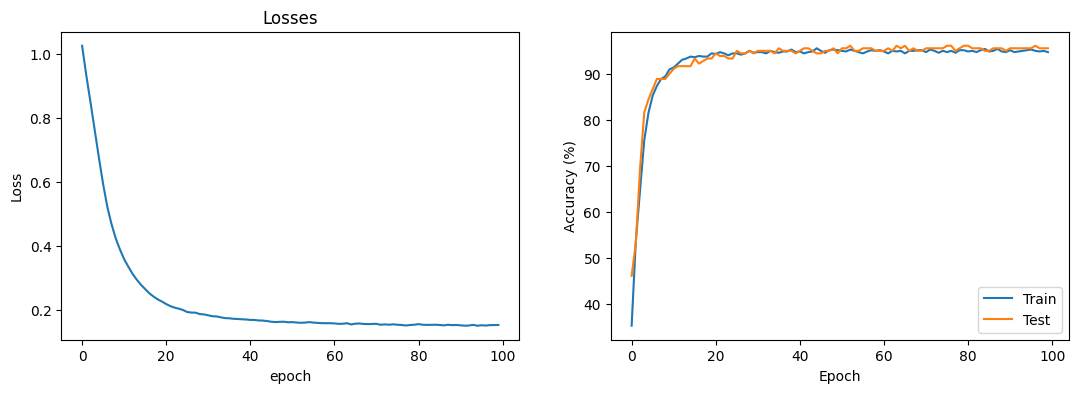

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].plot(losses.detach())
ax[0].set_ylabel('Loss')
ax[0].set_xlabel('epoch')
ax[0].set_title('Losses')

ax[1].plot(trainAcc, label='Train')
ax[1].plot(testAcc, label='Test')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_xlabel('Epoch')
ax[1].legend()
plt.show()

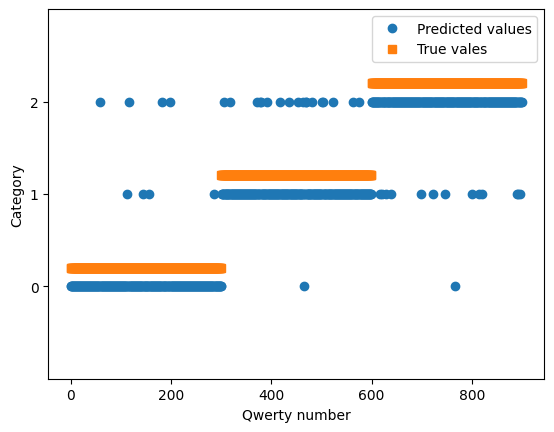

In [29]:
yHat = net(data)
predictions = torch.argmax(yHat, axis=1)

plt.plot(predictions, 'o', label='Predicted values')
plt.plot(labels+.2, 's', label='True vales')
plt.xlabel('Qwerty number')
plt.ylabel('Category')
plt.yticks([0,1,2])
plt.ylim([-1,3])
plt.legend()
plt.show()

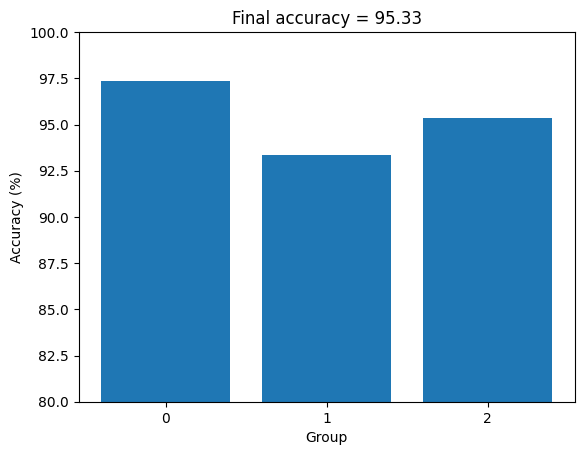

In [32]:
accuracy = (predictions == labels).float()

totalAcc = torch.mean(100*accuracy).item()

accuracyByGroup = np.zeros(3)
for i in range(3):
    accuracyByGroup[i] = 100*torch.mean(accuracy[labels==i])

plt.bar(range(3), accuracyByGroup)
plt.ylim([80, 100])
plt.xticks([0,1,2])
plt.xlabel('Group')
plt.ylabel('Accuracy (%)')
plt.title(f"Final accuracy = {totalAcc:.2f}")
plt.show()

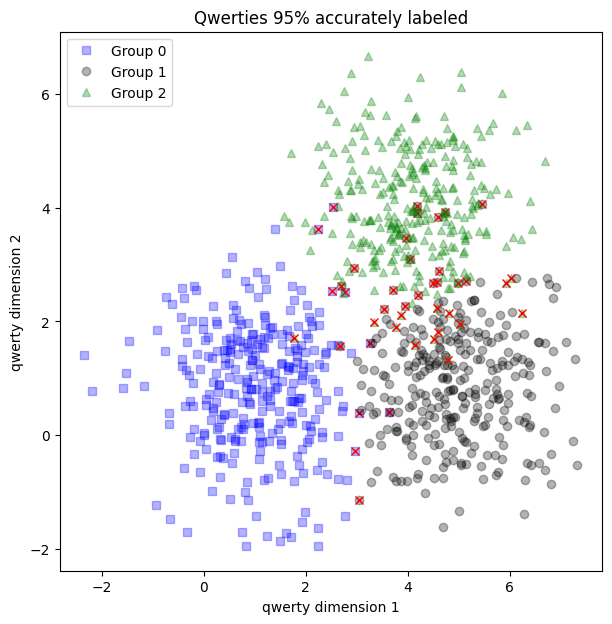

In [33]:
colorShapes = ['bs', 'ko', 'g^']

fig = plt.figure(figsize=(7,7))

for i in range(3):
    plt.plot(data[labels==i,0], data[labels==i, 1], colorShapes[i],
             alpha=.3, label=f"Group {i}")

    idxErr = (accuracy==0) & (labels==i)
    plt.plot(data[idxErr, 0], data[idxErr, 1], 'rx')

plt.title(f"Qwerties {totalAcc:.0f}% accurately labeled")
plt.xlabel("qwerty dimension 1")
plt.ylabel("qwerty dimension 2")
plt.legend()
plt.show()